# 🎭📃 Text Emotion Analysis

# 1. Bussiness Understanding

> #### Project Overview :

Text Emotion Analysis is a Natural Language Processing (NLP) task where we classify human emotions (like joy, sadness, anger, fear, etc.) from textual data such as messages, tweets, or reviews.

> #### Problem Statement :

In our modern digital era, individuals share feelings via text (social platforms, messaging, reviews), yet computers lack the innate ability to decode human affect.

> #### Project Objective :

**Develop a predictive model** capable of analyzing unstructured text to identify underlying human sentiments.

**Accurately categorize emotions** into specific classes, including:

-  *Joy* 
-  *Sadness* 
-  *Anger* 
-  *Fear* 
-  *Love* 
-  *Surprise*  etc


# 2. Data Understanding – Text Emotion Dataset

This dataset is specifically curated for supervised emotion classification. It serves as the "ground truth" for training, where each text entry is manually or programmatically mapped to a human psychological state

> #### Dataset Structure
The file typically contains two primary columns:

| Column Name | Type | Description |
| :--- | :--- | :--- |
| **Text** | String | The input sentence, tweet, or message (e.g., *"I'm so thrilled about this!"*). |
| **Emotion** | Categorical | The target label representing the primary feeling (e.g., **joy**, **sadness**). |




## 2.1 Importing Libraries

In [2]:
!pip install transformers==4.41.2 tokenizers==0.19.1 -q
!pip install tf_keras -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 59.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import string
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
import tf_keras as tfk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import legacy as legacy_optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2026-04-07 10:24:24.715449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775557464.877539      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775557464.923876      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plug

## 2.2 Loading Dataset

In [5]:
data = pd.read_csv("/kaggle/input/datasets/prajwalnayakat/text-emotion/final_dataset.csv")
data

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm
...,...,...
106350,i used to feel strongly about how much i hated...,hate
106351,i feel like i just got a spirit booster this r...,surprise
106352,i could come up with is that i was really feel...,anger
106353,i find it really it helps to have an outfit of...,relief


## 2.3 Rows and Columns
Checking the Total Rows and Columns

In [6]:
print(f"Total Rows are: {data.shape[0]} and Columns are: {data.shape[1]}")

Total Rows are: 106355 and Columns are: 2


## 2.4 Data Info

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106355 entries, 0 to 106354
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     106355 non-null  object
 1   emotion  106355 non-null  object
dtypes: object(2)
memory usage: 1.6+ MB


## 2.5 Checking Null Values

In [8]:
data.isnull().sum()

text       0
emotion    0
dtype: int64

## 2.6 Checking Duplicated

In [9]:
data.duplicated().sum()

np.int64(25529)

## 2.7 Removing Duplicates

In [10]:
data= data.drop_duplicates()

### 2.7 Unique Emotions

In [11]:
print("Total Emotion Classes: ", data["emotion"].nunique())
data["emotion"].unique()

Total Emotion Classes:  11


array(['fun', 'surprise', 'neutral', 'enthusiasm', 'happiness', 'hate',
       'sadness', 'empty', 'love', 'relief', 'anger'], dtype=object)

In [12]:
# Total Value Counts
emotion_counts = data["emotion"].value_counts()
emotion_counts

emotion
neutral       9907
sadness       9316
happiness     9155
love          8586
surprise      7915
anger         7465
relief        7279
fun           6240
hate          6206
enthusiasm    5250
empty         3507
Name: count, dtype: int64

# 3. Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) was performed to understand the data distribution, identify class imbalance, and detect issues such as duplicates and noise before model building.

In [13]:
sns.set_theme(style="whitegrid",
              rc= {"grid.linestyle" : "--" },
              palette = "pastel")
plt.rcParams["figure.figsize"] = (7,4)

## 3.1 Class Distribution

- The dataset is mostly balanced, with most emotion classes having around 10,000 samples.
- However, the **"empty"** class has significantly fewer samples (~6,358), indicating slight class imbalance.

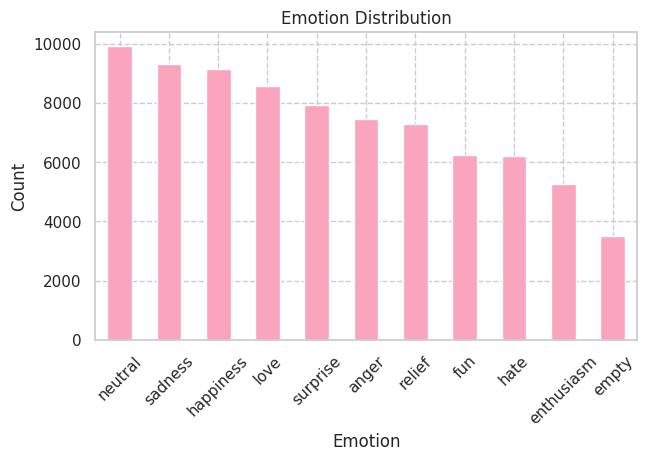

In [14]:
data["emotion"].value_counts().plot(kind = "bar", color = "#FAA4BD")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.show()

## 3.2 Text Length Analysis

- Most text samples are short to medium in length.
- A few long texts are present, indicating some variability in data.
- The distribution is slightly right-skewed (more shorter texts than longer ones).
- This suggests the dataset is similar to conversational or social media text.

In [15]:
data["text_length"] = data["text"].apply(len)
data["text_length"].describe()

count    80826.000000
mean       100.295994
std         57.542460
min          1.000000
25%         57.000000
50%         90.000000
75%        130.000000
max        830.000000
Name: text_length, dtype: float64

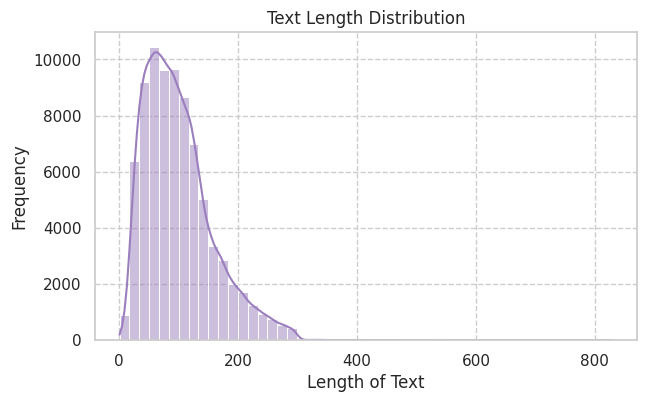

In [16]:
sns.histplot(data["text_length"], bins = 50, color = "#9B7EBD", kde =True)
plt.title("Text Length Distribution")
plt.xlabel("Length of Text")
plt.ylabel("Frequency")
plt.show()

## 3.3 Word Count

- Most texts contain a small number of words.
- The distribution is right-skewed, with few texts having high word counts.
- This indicates the data mainly consists of short, concise sentences.

In [17]:
data["word_count"] = data["text"].apply(lambda x: len(str(x).split()))
data["word_count"].describe()

count    80826.000000
mean        19.714597
std         11.339582
min          1.000000
25%         11.000000
50%         18.000000
75%         26.000000
max        178.000000
Name: word_count, dtype: float64

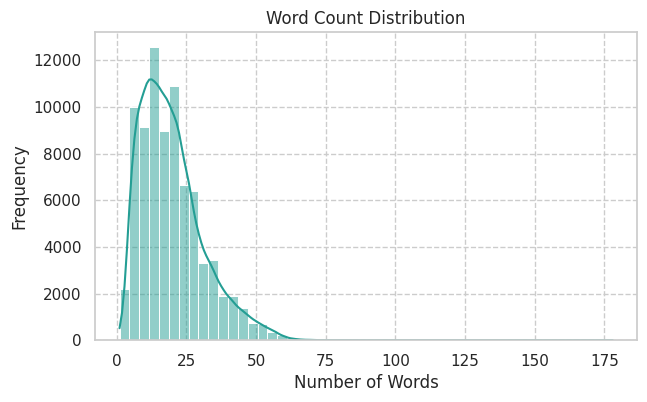

In [18]:
plt.figure()
sns.histplot(data["word_count"], bins = 50, kde = True, color = "#249E94")
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


## 3.4 Most Frequent Words
The most frequent words in the dataset include common stopwords such as “i”, “and”, “to”, and “the”, along with domain-specific words like “feel” and “feeling”, indicating that the dataset is centered around expressing emotions and personal experiences.

In [19]:
all_words = " ".join(data["text"]).split()
word_freq = Counter(all_words)
word_freq.most_common(10)

[('i', 105515),
 ('and', 49243),
 ('to', 46154),
 ('the', 43234),
 ('feel', 41195),
 ('a', 30408),
 ('of', 24629),
 ('that', 23367),
 ('my', 22388),
 ('feeling', 20583)]

## 3.5 Emotion-wise Insights
Emotion-wise analysis shows that the average word count varies slightly across classes, with emotions like love and relief having longer expressions, while surprise, sadness, and neutral tend to have shorter texts, indicating differences in how users express various emotions.

In [20]:
s = data.groupby("emotion")["word_count"].mean()
s = pd.DataFrame(s)
s

,word_count
emotion,
anger,20.170931
empty,19.159110
enthusiasm,20.045143
fun,20.527724
happiness,18.736974
hate,21.022237
love,22.723038
neutral,18.130817
relief,21.621377


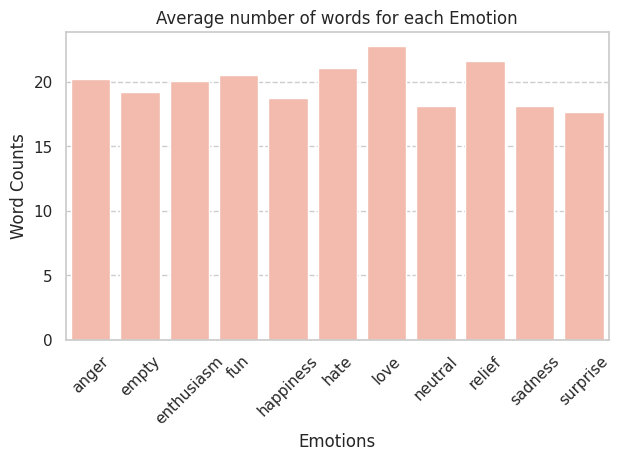

In [21]:
plt.figure
sns.barplot(data = s, x = "emotion", y = "word_count", color = "#FFB4A2")
plt.xlabel("Emotions")
plt.ylabel("Word Counts")
plt.xticks(rotation = 45)
plt.title("Average number of words for each Emotion")
plt.show()

## 3.6 Text WordCloud

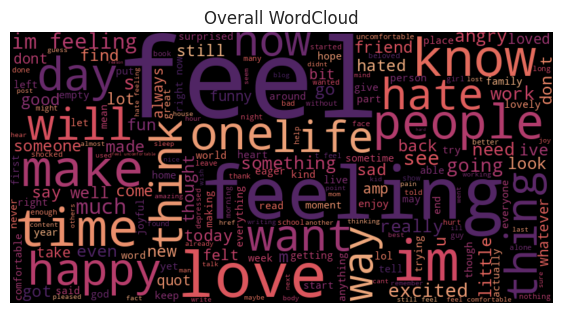

In [22]:
text = " ".join(data["text"])

stop_words = set(STOPWORDS)
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = "black",
    colormap = "flare",
    stopwords = stop_words
    
).generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Overall WordCloud")
plt.show()

## 3.7 Emotion-wise WordCloud

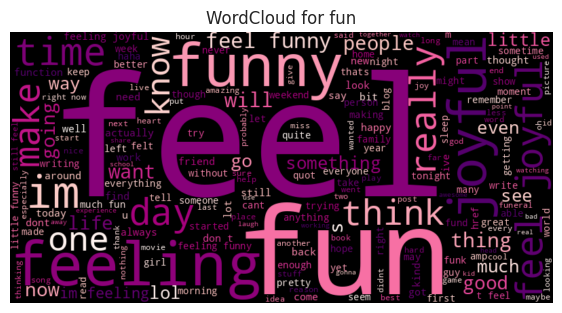

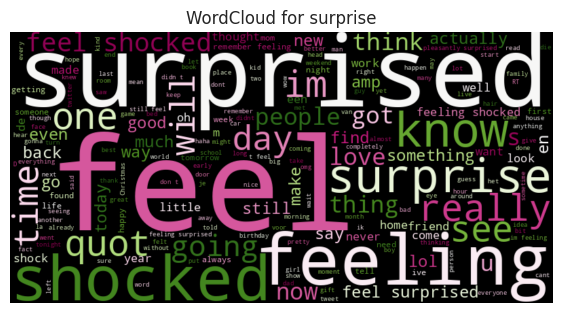

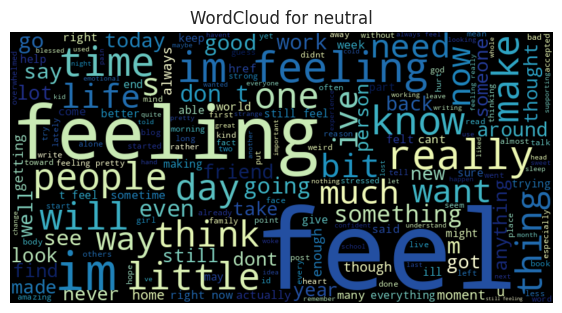

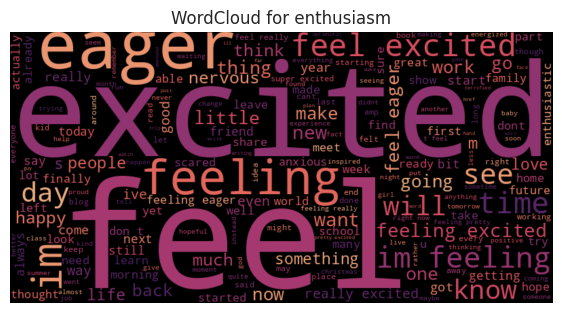

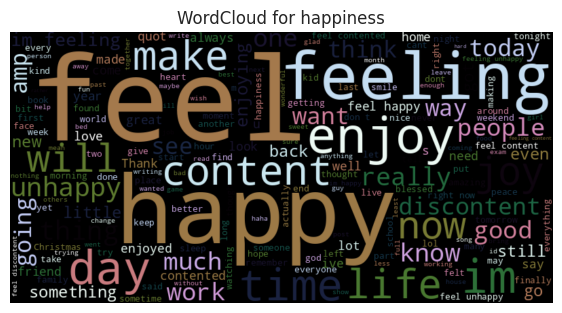

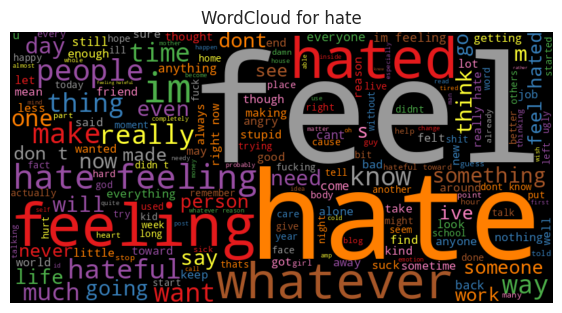

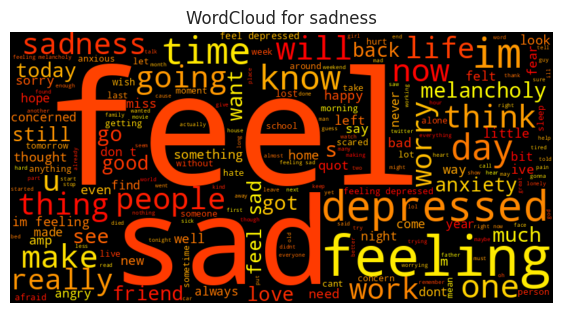

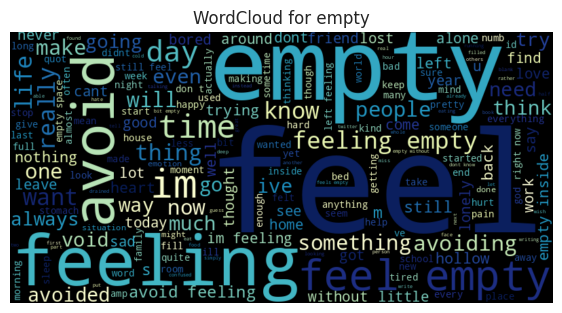

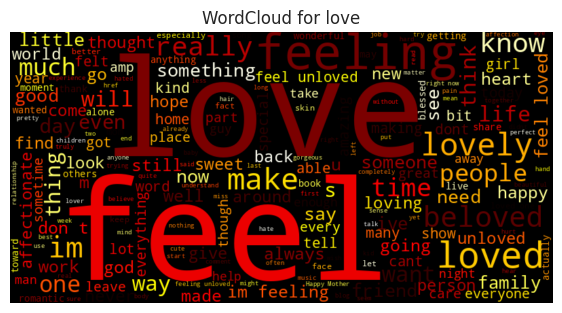

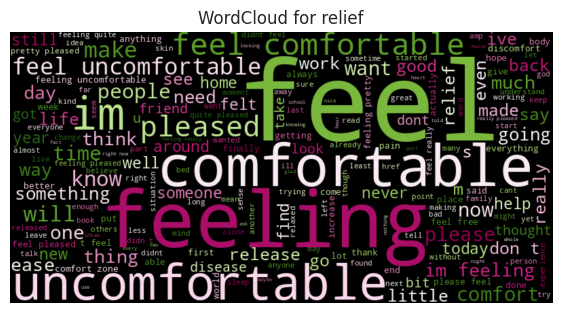

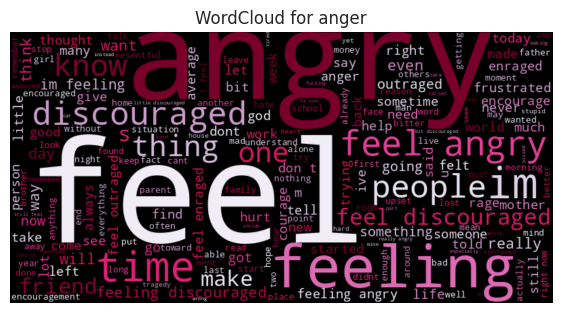

In [23]:
emotions = data["emotion"].unique()
colors = ["RdPu", "PiYG", "YlGnBu", "flare", "cubehelix_r", "Set1", "autumn", "YlGnBu", "hot", "PiYG_r", "PuRd_r"]

for idx, i in enumerate(emotions):
    text = " ".join(data[data["emotion"]==i]["text"])

    wordcloud = WordCloud(
        width = 800,
        height = 400,
        background_color = "black",
        stopwords = STOPWORDS,
        colormap = colors[idx]
     ).generate(text)

    plt.figure()
    plt.imshow(wordcloud, interpolation = "bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {i}")
    plt.show()
    

# 4. Data Cleaning

- Text data was cleaned by converting to lowercase and removing punctuation, numbers, and special characters.
- Extra spaces were also removed to standardize the text.


In [24]:
def clean_text(x):
    x = str(x).lower()

    # Punctuation Removed
    for i in x:
        if i in string.punctuation:
            x = x.replace(i, "")          
    x = "".join([char for char in x if not char.isdigit()]) # removing digits
    x = " ".join(x.split()) # Removing Spaces
    
    return x

data["cleaned_text"] = data["text"].apply(clean_text)

In [25]:
data[["text","cleaned_text"]].sample(5)

,text,cleaned_text
61790,i feel irritated with the spray amp count vert...,i feel irritated with the spray amp count vert...
47769,i can express whatever im feeling whether it a...,i can express whatever im feeling whether it a...
35341,i take comfort being paralyzed now for years a...,i take comfort being paralyzed now for years a...
83793,i feel that i have a funny looking hairdo funn...,i feel that i have a funny looking hairdo funn...
91236,i should also note that it feels gentle as lon...,i should also note that it feels gentle as lon...


# 5. Text Preprocessing

1. **Tokenization** - Breaking sentence into individual words.
2. **Stopword Removal** - Removing useless/common words (I, am, the, is, very)
3. **Lemmatization** - Converting to root form ("feeling" → "feel)

### 5.1 Initialization of stopwords and lemmatizer

In [26]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [27]:
def preprocess_text(text):
    text = str(text)

    # Tokenization
    words = word_tokenize(text)

    # Stopwords + Lemmatization
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            lem = lemmatizer.lemmatize(word)
            cleaned_words.append(lem)

    return " ".join(cleaned_words)

In [28]:
data["processed_text"] = data["cleaned_text"].apply(preprocess_text)
data[["cleaned_text", "processed_text"]].head()

,cleaned_text,processed_text
0,i feel rather funny ending with so many dupes ...,feel rather funny ending many dupe always pref...
1,i feel surprised by the result,feel surprised result
2,i am officially feeling festive,officially feeling festive
3,i suddenly found myself standing before this w...,suddenly found standing woman dressed like pri...
4,i look at the meager pile of food i purchased ...,look meager pile food purchased week feeling p...


# 6. Feature Engineering 

- Text data was converted into numerical form using TF-IDF vectorization.
- Categorical labels (emotions) was converted into numerical form so models can process them.


## 6.1 Splitting in x and y

In [29]:
x = data["processed_text"]
y = data["emotion"]

## 6.1 Term Frequency - Inverse Document Frequency (TF-IDF)

TF-IDF (Term Frequency–Inverse Document Frequency) assigns higher importance to meaningful words while reducing the influence of commonly occurring words.

The parameter ngram_range=(1, 2) enables the extraction of both unigrams (single words) and bigrams (pairs of consecutive words), allowing the model to capture more context from the text.

- Example, the sentence "i love coding" is transformed into: ['i', 'love', 'coding', 'i love', 'love coding'], representing both individual words and word pairs.


In [30]:
tfidf = TfidfVectorizer(max_features = 5000,
                       ngram_range = (1,2),
                       min_df = 2,
                       max_df = 0.9
                       )

### 6.1.1 Converting Text → Vectors

In [31]:
x_t = tfidf.fit_transform(x) 

In [32]:
# Converting to dataframe

x_df = pd.DataFrame(x_t.toarray(), columns = tfidf.get_feature_names_out())
x_df

,aan,abandoned,ability,able,able feel,able get,abroad,absence,absolute,absolutely,...,youtube,youve,yr,yu,yummy,yup,zijn,zo,zombie,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80822,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80823,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6.2 Label Encoder
LabelEncoder converts categorical labels (like emotions) into numerical form so models can process them.

In [33]:
le = LabelEncoder()
y_encoded = le.fit_transform(data["emotion"])
y_encoded

array([ 3, 10,  7, ...,  5, 10,  7])

In [34]:
le.classes_

array(['anger', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love',
       'neutral', 'relief', 'sadness', 'surprise'], dtype=object)

In [35]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))

print(mapping)

{'anger': 0, 'empty': 1, 'enthusiasm': 2, 'fun': 3, 'happiness': 4, 'hate': 5, 'love': 6, 'neutral': 7, 'relief': 8, 'sadness': 9, 'surprise': 10}


# 7. Train Test Split

- The dataset was split into 80% training and 20% testing data.
- Stratification was applied to maintain the same distribution of emotion classes in both sets.

In [36]:
x_tfidf_train, x_tfidf_test, ytrain, ytest = train_test_split(x_t,y_encoded, test_size = 0.2, random_state= 42, stratify = y)

In [37]:
x_tfidf_train.shape, x_tfidf_test.shape, ytrain.shape, ytest.shape

((64660, 5000), (16166, 5000), (64660,), (16166,))

# 8. Baseline ML Models

Baseline Machine Learning models including Naive Bayes, Logistic Regression, and Random Forest were implemented to establish initial performance benchmarks for the emotion classification task.

## 8.1 Models Dictionary
A models dictionary was created to organize and compare multiple algorithms efficiently. It includes `Naive Bayes`, which is simple and fast for text data, `Logistic Regression`, which performs well for linear classification tasks, and `Random Forest`, which captures complex patterns by combining multiple decision trees.

In [38]:
models = {
    "Naive Bayes" : MultinomialNB(),
    "Logistic Regression" : LogisticRegression(max_iter = 200),
    "Random Forest" : RandomForestClassifier()
}

## 8.2 Model Fitting
Model performance was evaluated using the weighted F1-score, which considers both precision and recall while accounting for class imbalance, providing a balanced measure of overall model effectiveness.

The weighted F1-score is used because the dataset is imbalanced, meaning some emotion classes have more samples than others. It calculates the F1-score for each class and then takes a weighted average based on the number of samples in each class, ensuring that all classes are fairly represented in the final evaluation.

In [39]:
# Evaluate Function

def model_evaluate(model, xtrain, xtest, ytrain, ytest):
    model.fit(xtrain, ytrain)

    # Predict
    y_pred = model.predict(xtest)

    # Metrics
    acc= accuracy_score(ytest, y_pred)
    report = classification_report(ytest, y_pred)
    f1 = f1_score(ytest, y_pred, average = "weighted")
    cm = confusion_matrix(ytest, y_pred)

    return acc, report, f1, cm
    

## 8.3 Model Evaluation
Since this is a multi-class classification problem, I used weighted F1-score to account for class imbalance and get a more reliable performance metric.

In [40]:
results = {}

for name, model in models.items():
    print("="*25)
    print(f"{name}")
    print("="*25)

    acc, report, f1, cm = model_evaluate(model, x_tfidf_train, x_tfidf_test, ytrain, ytest)

    # Storing accuracy (acc) of each model using its name (name) as key”
    results[name] = acc

    print("Accuracy: ", acc)
    print("Classification Report: \n", report)
    print("F1 Score: ",f1)
    print("Confusion Matrix: ")
    print(cm)
    print("\n")

Naive Bayes
Accuracy:  0.684399356674502
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.70      0.74      1493
           1       0.98      0.53      0.69       702
           2       0.89      0.71      0.79      1050
           3       0.83      0.57      0.68      1248
           4       0.57      0.68      0.62      1831
           5       0.87      0.70      0.78      1241
           6       0.68      0.78      0.73      1717
           7       0.63      0.69      0.66      1982
           8       0.87      0.76      0.81      1456
           9       0.50      0.66      0.57      1863
          10       0.59      0.64      0.62      1583

    accuracy                           0.68     16166
   macro avg       0.75      0.68      0.70     16166
weighted avg       0.71      0.68      0.69     16166

F1 Score:  0.6896337319483173
Confusion Matrix: 
[[1041    3    3    7   42   15   45   86   17  173   61]
 [  24  371   

## 8.4 ML Model Results

- Random Forest achieved the highest accuracy (~85.9%), making it the best-performing model.
- Logistic Regression also performed strongly (~84.6%) with stable and balanced predictions.
- Naive Bayes served as a good baseline but showed lower performance (~73%).
- Overall, ensemble methods like Random Forest captured complex patterns better than simpler models.

In [41]:
results_df = pd.DataFrame(list(results.items()),
                         columns = ["Model", "Accuracy"])

results_df.sort_values(by = "Accuracy",ascending = False)

,Model,Accuracy
2,Random Forest,0.806136
1,Logistic Regression,0.802858
0,Naive Bayes,0.684399


# 9. Deep Learning (LSTM)

- Text data was converted into sequences using tokenization and padding.
- An LSTM model was used to capture sequential dependencies in text.
- The model architecture included an embedding layer, LSTM layer, and dense output layer.
- LSTM helps in understanding context and improves performance over traditional models.

## 9.1 Tokenization (Text → Sequence)

In [42]:
t = Tokenizer(num_words = 500)
t.fit_on_texts(x)

In [43]:
x_seq = t.texts_to_sequences(x)
x_seq[:5] # Text has been converted to sequence Numbers

[[1, 152, 46, 89, 45],
 [1, 52, 493],
 [2],
 [172, 197, 3, 106, 372, 2, 476, 288, 420],
 [66, 266, 77, 2, 75]]

In [44]:
len(t.word_index)

40939

## 9.2 Text Length Distribution Insight

- Most sentences are short (6–13 words).
- Very few long sentences (max = 79).
- Chose maxlen = 20 to efficiently cover majority of data.
- Based on this distribution, a sequence length of around 20 is sufficient to cover most of the data while avoiding excessive padding.

In [45]:
length = data["processed_text"].apply(lambda x: len(x.split()))
print(length.describe())

count    80826.000000
mean         9.837985
std          5.383010
min          0.000000
25%          6.000000
50%          9.000000
75%         13.000000
max         79.000000
Name: processed_text, dtype: float64


## 9.2 Padding( Equal Length)

Padding and embedding dimensions must align to maintain consistent input shape for sequence models.

In [46]:
x_pad = pad_sequences(x_seq, padding = "post", maxlen = 30)

In [47]:
x_pad.shape

(80826, 30)

## 9.3 Label Encoded

In [48]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

## 9.4 Train-Test Split 

Since TF-IDF and LSTM require different input representations, Separate train-test splits was performed for each approach to ensure proper data handling.

In [49]:
x_seq_train, x_seq_test, ytrain, ytest = train_test_split(x_pad, y_enc, test_size = 0.2, random_state = 42, stratify = y_enc)

In [50]:
x_seq_train.shape, x_seq_test.shape, ytrain.shape, ytest.shape

((64660, 30), (16166, 30), (64660,), (16166,))

In [51]:
ytrain

array([ 9,  1,  7, ...,  8,  5, 10])

## 9.5 BiLSTM Model

The BiLSTM (Bidirectional Long Short-Term Memory) model was implemented to capture context from both past and future words in a sequence. By processing text in both forward and backward directions, it improves understanding of sentence meaning, leading to better emotion classification compared to traditional LSTM.

In [52]:
model = Sequential()

# Embedding Layer
model.add(Embedding(40940,128, input_length=30)) #input_dim , output_dim

# LSTM Layer
model.add(Bidirectional(LSTM(64, return_sequences = True)))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(64,activation = "relu"))
model.add(Dense(11, activation = "softmax"))

I0000 00:00:1775557713.400344      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775557713.406180      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 9.6 Model Compilation

In [53]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

## 9.7 Traning Model
The model was trained using a **batch size of 32**, which balances memory efficiency and training speed by processing 32 samples in each iteration.

In [54]:
history = model.fit(
    x_seq_train, ytrain,
    epochs = 15,
    batch_size = 32,
    validation_data = (x_seq_test, ytest)
)

Epoch 1/15


I0000 00:00:1775557721.773623     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775557723.105879     157 service.cc:152] XLA service 0x7cccc4c9b1b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775557723.105917     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775557723.105922     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775557723.369494     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2021/2021 [==============================] - 55s 22ms/step - loss: 1.0444 - accuracy: 0.6765 - val_loss: 0.8127 - val_accuracy: 0.7516
Epoch 2/15
2021/2021 [==============================] - 32s 16ms/step - loss: 0.8203 - accuracy: 0.7487 - val_loss: 0.7861 - val_accuracy: 0.7576
Epoch 3/15
2021/2021 [==============================] - 32s 16ms/step - loss: 0.7949 - accuracy: 0.7552 - val_loss: 0.7811 - val_accuracy: 0.7589
Epoch 4/15
2021/2021 [==============================] - 31s 15ms/step - loss: 0.7841 - accuracy: 0.7584 - val_loss: 0.7777 - val_accuracy: 0.7624
Epoch 5/15
2021/2021 [==============================] - 32s 16ms/step - loss: 0.7747 - accuracy: 0.7613 - val_loss: 0.7725 - val_accuracy: 0.7657
Epoch 6/15
2021/2021 [==============================] - 31s 15ms/step - loss: 0.7638 - accuracy: 0.7641 - val_loss: 0.7694 - val_accuracy: 0.7642
Epoch 7/15
2021/2021 [==============================] - 31s 15ms/step - loss: 0.7561 - accuracy: 0.7668 - val_loss: 0.7794 - val_accura

## 9.8 BiLSTM Evaluate

In [55]:
loss, acc = model.evaluate(x_seq_test, ytest)
print("Test Accuracy: ",acc)

506/506 [==============================] - 3s 6ms/step - loss: 0.8114 - accuracy: 0.7583
Test Accuracy:  0.7583199143409729


In [56]:
# Prediction - “The model outputs probabilities, and argmax selects the class with the highest probability as the final prediction.
y_pred = model.predict(x_seq_test) # Predictions are in 
y_pred_classes = np.argmax(y_pred, axis = 1)
y_pred_classes

506/506 [==============================] - 4s 5ms/step


array([9, 5, 0, ..., 2, 0, 8])

In [57]:
print("="*25)
print("BiLSTM Model")
print("="*25)

print("\nAccuracy: ", accuracy_score(ytest, y_pred_classes))
print("Classification Report: \n",classification_report(ytest, y_pred_classes))
print("F1 Score: ",f1_score(ytest, y_pred_classes, average= "weighted"))
print("Confusion Matrix: ")
print(confusion_matrix(ytest, y_pred_classes))
print("\n")


BiLSTM Model

Accuracy:  0.7583199307187926
Classification Report: 
               precision    recall  f1-score   support

           0       0.82      0.63      0.71      1493
           1       0.99      0.65      0.78       702
           2       1.00      0.83      0.90      1050
           3       0.82      0.67      0.74      1248
           4       0.69      0.76      0.72      1831
           5       0.96      0.87      0.91      1241
           6       0.93      0.87      0.90      1717
           7       0.66      0.93      0.77      1982
           8       0.92      0.76      0.83      1456
           9       0.59      0.63      0.61      1863
          10       0.56      0.68      0.61      1583

    accuracy                           0.76     16166
   macro avg       0.81      0.75      0.77     16166
weighted avg       0.78      0.76      0.76     16166

F1 Score:  0.7623612077662487
Confusion Matrix: 
[[ 943    0    0    9   62   11    3  212   13  135  105]
 [  15  453

## 9.9 BiLSTM Results

- Achieved ~75.8% accuracy with stable performance.
- Strong performance in classes 2, 5, and 6 (high F1-scores).
- Excellent recall for class 7 (~0.93).
- Lower performance in classes 9 and 10 due to similar emotion overlap.

# 10. BERT (Transformer Model)

BERT is a pretrained transformer-based model that captures **bidirectional context**, enabling a deeper understanding of word meanings.

It leverages **transformer architecture** to learn rich, contextual relationships in text, making it more effective than traditional models.

## 10.1 Loading Tokenizer

The **BERT tokenizer** is loaded using `bert-base-uncased`, which converts text into tokens suitable for model input.


In [58]:
bt = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

## 10.2 Tokenization



In [59]:
x_bert = bt(
    data["cleaned_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="tf"
)
x_bert

{'input_ids': <tf.Tensor: shape=(80826, 128), dtype=int32, numpy=
array([[ 101, 1045, 2514, ...,    0,    0,    0],
       [ 101, 1045, 2514, ...,    0,    0,    0],
       [ 101, 1045, 2572, ...,    0,    0,    0],
       ...,
       [ 101, 1045, 2113, ...,    0,    0,    0],
       [ 101, 2026, 2155, ...,    0,    0,    0],
       [ 101, 1045, 2514, ...,    0,    0,    0]], dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(80826, 128), dtype=int32, numpy=
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(80826, 128), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=int32)>}

### 10.2.1 Converting Tensors to Numpy

The BERT outputs are converted from tensors to NumPy arrays for easier processing and compatibility with other libraries.

In [60]:
x_ids = x_bert["input_ids"].numpy()
x_mask = x_bert["attention_mask"].numpy()

## 10.3 Label Encoding

In [61]:
y_enc = le.fit_transform(data["emotion"])

## 10.4 Train Test Split

The dataset is split into training and testing sets (80-20 split) while maintaining class distribution using stratification.

In [62]:
x_bert_train, x_bert_test, ytrain, ytest = train_test_split(
    x_ids,
    y_enc,
    test_size = 0.2,
    stratify = y_enc,
    random_state = 42
)

- **x_mask**: Attention mask → tells BERT which tokens are real and which are padding  
  - `1` = actual word  
  - `0` = padding (ignore this)

- **x_train_mask / x_test_mask**: Split attention masks for training and testing

In [63]:
x_train_mask, x_test_mask, _, _ = train_test_split(
    x_mask,
    y_enc,
    test_size = 0.2,
    stratify = y_enc,
    random_state = 42
)

## 10.5 Loading BERT Model

The **BERT model for sequence classification** is loaded using `bert-base-uncased` with 11 output labels.

- bert-base-uncased: A pretrained BERT model with lowercased text.
- num_labels=11: Specifies the number of output classes for classification.


In [64]:
model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=11
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 10.6 Model Compiliation

The model is compiled using the **Adam optimizer** with a very small learning rate to ensure stable fine-tuning of BERT.

- **Adam (learning_rate = 2e-5)**: Prevents large updates, preserving pretrained knowledge  
- **from_logits = True**: Indicates that BERT outputs raw logits, so softmax is applied internally by the loss function

In [65]:
optimizer = tfk.optimizers.Adam(learning_rate=2e-5)
model.compile(
    optimizer=optimizer, 
    loss=tfk.losses.SparseCategoricalCrossentropy(from_logits=True), 
    metrics=["accuracy"]
)

## 10.7 Early Stopping 

Early stopping technique is used to prevent **overfitting** by stopping training when the model's performance on validation data stops improving.

It monitors a metric (like validation loss) and halts training if no improvement is seen after a certain number of epochs.

In [66]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 2,
    restore_best_weights = True
)

## 10.8 Learning Rate Scheduler

A learning rate scheduler adjusts the **learning rate during training** to improve performance and convergence.

It typically reduces the learning rate over time, helping the model learn efficiently and avoid overshooting the optimal solution.

In [67]:
lr_scheduler = ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.3,
    patience = 1,
    min_lr = 1e-6,
    verbose = 1
)

## 10.9 Class Weights

Class weights are used to handle **imbalanced datasets** by assigning higher importance to underrepresented classes.

This helps the model learn more effectively from minority classes and improves overall performance.

In [68]:
class_weights = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(ytrain),
    y = ytrain
)

class_weights = dict(enumerate(class_weights))

## 10.7 Traning

The model is trained using input IDs and attention masks, along with validation data to monitor performance.

In [69]:
history = model.fit(
    {
        "input_ids": x_bert_train,
        "attention_mask" : x_train_mask
    },
    ytrain,
    validation_data = (
        {
            "input_ids" : x_bert_test,
            "attention_mask" : x_test_mask
            
        },
        ytest
    ),
    epochs = 3,
    batch_size = 32,
    callbacks=[early_stop, lr_scheduler],
    class_weight = class_weights
)

Epoch 1/3
2021/2021 [==============================] - 1882s 902ms/step - loss: 0.7240 - accuracy: 0.7705 - val_loss: 0.4952 - val_accuracy: 0.8369 - lr: 2.0000e-05
Epoch 2/3
2021/2021 [==============================] - 1818s 900ms/step - loss: 0.4327 - accuracy: 0.8575 - val_loss: 0.4709 - val_accuracy: 0.8468 - lr: 2.0000e-05
Epoch 3/3
2021/2021 [==============================] - ETA: 0s - loss: 0.3251 - accuracy: 0.8917
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.000000212225132e-06.
2021/2021 [==============================] - 1819s 900ms/step - loss: 0.3251 - accuracy: 0.8917 - val_loss: 0.4776 - val_accuracy: 0.8501 - lr: 2.0000e-05


## 10.8 Prediction

During prediction, **Softmax** converts logits into probability scores for each class.

In [70]:
y_pred = model.predict({
    "input_ids": x_bert_test,
    "attention_mask": x_test_mask
}).logits

506/506 [==============================] - 155s 301ms/step


### 10.8.1 Converting logits -> class labels

The **argmax** function is then used to select the class with the highest probability as the final prediction.

In [71]:
y_pred_classes = np.argmax(y_pred, axis = 1)

## 10.9 Evaluation

In [72]:
print("=" * 25)
print("BERT Model")
print("=" * 25)

print("Accuracy: ", accuracy_score(ytest, y_pred_classes))
print("F1 Score: ", f1_score(ytest, y_pred_classes, average="weighted"))

print("Classification Report:\n", classification_report(ytest, y_pred_classes))

print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred_classes))

BERT Model
Accuracy:  0.8467771866881109
F1 Score:  0.8477524858144104
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85      1493
           1       0.74      0.83      0.78       702
           2       0.87      0.87      0.87      1050
           3       0.87      0.80      0.83      1248
           4       0.79      0.80      0.79      1831
           5       0.91      0.90      0.91      1241
           6       0.98      0.92      0.95      1717
           7       0.97      0.96      0.97      1982
           8       0.96      0.90      0.93      1456
           9       0.71      0.74      0.72      1863
          10       0.72      0.70      0.71      1583

    accuracy                           0.85     16166
   macro avg       0.85      0.85      0.85     16166
weighted avg       0.85      0.85      0.85     16166

Confusion Matrix:
 [[1337    9    5    4   16   12    2   12    5   67   24]
 [  18  582    

## 10.10 Confusion Matrix

['anger', 'empty', 'enthusiasm', 'fun', 'happiness', 'hate', 'love', 'neutral', 'relief', 'sadness', 'surprise']


Text(0.5, 76.24999999999999, 'Predicted')

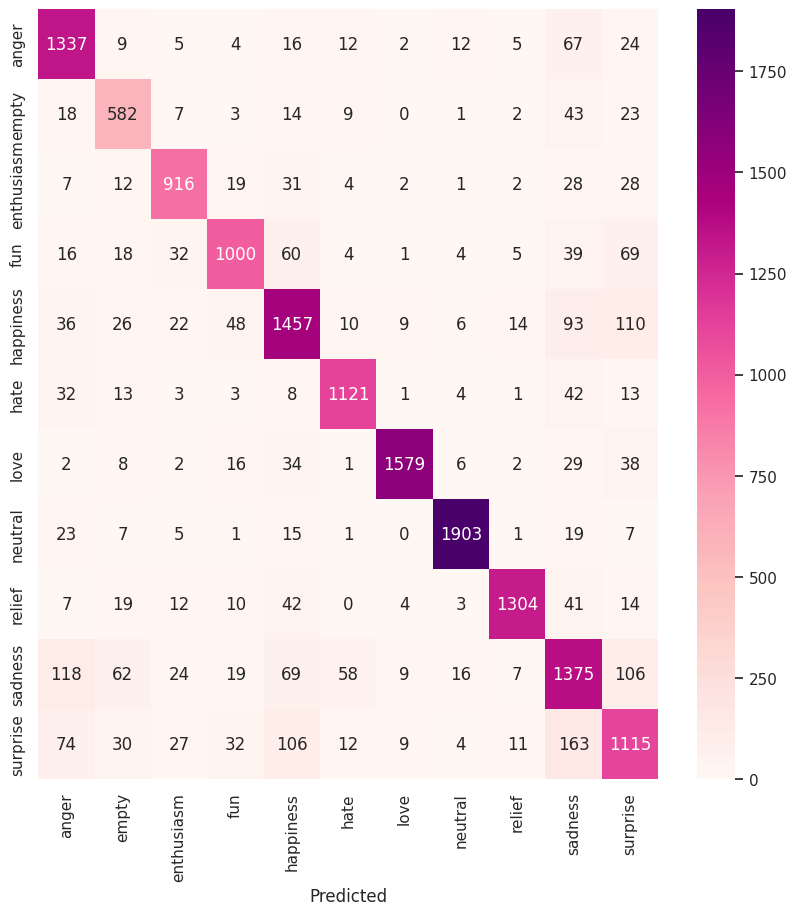

In [73]:
class_names = list(le.classes_)
print(class_names)

cm = confusion_matrix(ytest, y_pred_classes)

plt.figure(figsize = (10,10))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "RdPu",
    xticklabels = class_names,
    yticklabels = class_names
    
)

plt.xlabel("Predicted")

# 11. Saving The BERT Model

The trained BERT model is saved to disk for future use or deployment.

In [74]:
model.save_pretrained("bert_emotion_model")
bt.save_pretrained("bert_emotion_tokenizer")

('bert_emotion_tokenizer/tokenizer_config.json',
 'bert_emotion_tokenizer/special_tokens_map.json',
 'bert_emotion_tokenizer/vocab.txt',
 'bert_emotion_tokenizer/added_tokens.json')

In [75]:
import shutil

shutil.make_archive("final_bert_model", "zip", "/kaggle/working")

'/kaggle/working/final_bert_model.zip'

In [78]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

# 12. Testing the Model

The trained model is tested on a **random sentence** to evaluate its prediction capability on unseen data.

This helps verify how well the model generalizes to real-world inputs.

In [76]:
model = TFBertForSequenceClassification.from_pretrained("bert_emotion_model")
tokenizer = BertTokenizer.from_pretrained("bert_emotion_tokenizer")

Some layers from the model checkpoint at bert_emotion_model were not used when initializing TFBertForSequenceClassification: ['dropout_39']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at bert_emotion_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [77]:
text = ["ohh my god"]

test = tokenizer(
    text,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="tf"
)

pred = model.predict(test).logits
pred_class = np.argmax(pred, axis=1)
print(le.inverse_transform(pred_class))

1/1 [==============================] - 3s 3s/step
['surprise']


# 12. Conclusion 

* **Developed a comprehensive end-to-end NLP pipeline** for emotion classification, encompassing exploratory data analysis (EDA), preprocessing, and multi-architectural modeling.
* **Benchmarked traditional Machine Learning models**, identifying Random Forest as the top baseline performer with **80% accuracy**.
* **Implemented Deep Learning (BiLSTM) and Transformers (BERT)**, with BERT achieving a superior **84% accuracy and 85% F1-score** by capturing complex contextual nuances.
* **Optimized model stability** through rigorous data cleaning and deduplication, which served as a primary driver for performance gains.
* **Evaluated trade-offs** between computational efficiency and accuracy, ultimately deploying a robust BERT-based solution suitable for real-world applications.

